# FreshMind — Notebook 03: Modelo v2 (texto + contexto) y artefactos
**TFM · Máster Data Science, Big Data y Business Analytics · UCM 2026 · Alumna: Daniela Melendez**

## Por qué existe este notebook

El modelo del Notebook 01 (categoría + estado + lugar + referencia) alcanza un F1-macro de 0,70.
Su techo está en las *features*: dentro de una misma categoría conviven productos con vidas útiles
muy distintas (leche abierta: 7 días; queso curado: meses). Un modelo que solo ve la categoría no
puede separarlos, y una tabla de "clase mayoritaria por combinación" obtendría prácticamente el mismo resultado.

Este notebook introduce el **nombre del producto como texto** (TF-IDF sobre el nombre en español) y
evalúa con validación **leave-product-out** (`GroupKFold` por producto): el modelo nunca ve en test un
producto que vio en entrenamiento. Es la pregunta que importa para la app: *¿qué pasa cuando la usuaria
escribe un producto que no está en el catálogo FoodKeeper?*

Además genera dos artefactos que la app v2 necesita:
- `vida_util_app.parquet`: días de vida útil FoodKeeper por producto y escenario (para calcular fechas).
- `modelo_v2.pkl` + `label_encoder_v2.pkl`: modelo con texto para productos fuera de catálogo.


In [1]:
# 1. Librerías y Drive
!pip install -q xgboost==3.4.1 scikit-learn==1.9.1
import pandas as pd, numpy as np, joblib, re
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
RUTA = '/content/drive/MyDrive/TFM_FreshMind/'

features = pd.read_parquet(RUTA + 'features_modulo1.parquet')
print(features.shape)
features.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.4 MB/s eta 0:00:00
Mounted at /content/drive
(1226, 7)


,nombre_es,categoria_es,estado,lugar,referencia,dias_vida_util,urgencia
0,Jerky/Carne seca - Casero,Carne no perecedera,cerrado,despensa,fabricacion,30.0,verde
1,"Tarta de fruta - Manzana,melocotón,arándano,al...",Panadería,cerrado,despensa,fabricacion,1.0,rojo
6,Azúcar - Negra,Repostería y cocina,cerrado,despensa,fabricacion,3650.0,verde
7,Azúcar - Granulada,Repostería y cocina,cerrado,despensa,fabricacion,3650.0,verde
8,Azúcar - Para pastelería/confitería,Repostería y cocina,cerrado,despensa,fabricacion,3650.0,verde


## 2. Artefacto 1: tabla de vida útil para la app

La app v2 usa el dato FoodKeeper directamente cuando el producto está en catálogo y recurre al modelo solo cuando no lo está.

In [2]:
# 2. Días de vida útil por producto y escenario (mínimo = criterio conservador)
vida = (features.groupby(['nombre_es', 'estado', 'lugar', 'referencia'], as_index=False)
                ['dias_vida_util'].min())
vida.to_parquet(RUTA + 'vida_util_app.parquet', index=False)
print("Escenarios guardados:", len(vida))
vida.sample(5, random_state=1)

Escenarios guardados: 1224


,nombre_es,estado,lugar,referencia,dias_vida_util
685,"Maní o cacahuate - Hervidos, con cáscara",cerrado,congelador,fabricacion,3650.0
793,Palomitas de maíz - Paquetes para el microondas,cerrado,despensa,compra,180.0
159,"Café - Molido en casa, no al vacío",cerrado,congelador,fabricacion,365.0
1210,Yogur,cerrado,nevera,compra,7.0
341,Cordero - Carne molida,cerrado,congelador,compra,90.0


## 3. Baselines honestos

Antes de proponer un modelo nuevo, medimos qué consigue lo más simple con la misma validación.

In [3]:
# 3. Validación leave-product-out y baselines
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(features['urgencia'])
grupos = features['nombre_es']
gkf = GroupKFold(n_splits=5)
CONTEXTO = ['categoria_es', 'estado', 'lugar', 'referencia']

def evaluar(fn_predecir, nombre):
    """fn_predecir(train_df, y_train, test_df) -> predicciones. Devuelve métricas medias."""
    accs, f1s = [], []
    for tr, te in gkf.split(features, y, grupos):
        pred = fn_predecir(features.iloc[tr], y[tr], features.iloc[te])
        accs.append(accuracy_score(y[te], pred)); f1s.append(f1_score(y[te], pred, average='macro'))
    print(f"{nombre:45s} acc={np.mean(accs):.3f}  F1-macro={np.mean(f1s):.3f}")
    return {'Modelo': nombre, 'Accuracy': round(np.mean(accs), 3), 'F1-macro': round(np.mean(f1s), 3)}

# Baseline 1: clase mayoritaria global
def b_mayoritaria(tr, ytr, te):
    return np.full(len(te), np.bincount(ytr).argmax())

# Baseline 2: tabla "clase mayoritaria por combinación" (lo que un tutor preguntaría)
def b_tabla(tr, ytr, te):
    t = tr[CONTEXTO].copy(); t['y'] = ytr
    tabla = t.groupby(CONTEXTO)['y'].agg(lambda s: s.value_counts().idxmax())
    global_mode = np.bincount(ytr).argmax()
    claves = list(zip(*[te[c] for c in CONTEXTO]))
    return np.array([tabla.get(k, global_mode) for k in claves])

resultados = [evaluar(b_mayoritaria, 'Baseline: clase mayoritaria'),
              evaluar(b_tabla,       'Baseline: tabla mayoritaria por combinación')]

Baseline: clase mayoritaria                   acc=0.692  F1-macro=0.273
Baseline: tabla mayoritaria por combinación   acc=0.819  F1-macro=0.682


In [4]:
# 4. Modelo v1 (Notebook 01) bajo la MISMA validación, para comparar de forma justa
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

def xgb():
    return XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                         random_state=42, eval_metric='mlogloss')

def m_v1(tr, ytr, te):
    pipe = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore')), ('clf', xgb())])
    pipe.fit(tr[CONTEXTO], ytr, clf__sample_weight=compute_sample_weight('balanced', ytr))
    return pipe.predict(te[CONTEXTO])

resultados.append(evaluar(m_v1, 'v1: XGBoost solo contexto (NB01)'))

v1: XGBoost solo contexto (NB01)              acc=0.794  F1-macro=0.683


## 4. Modelo v2: el nombre del producto como texto

TF-IDF de palabras (unigramas y bigramas) sobre `nombre_es`, concatenado con el contexto. Probamos dos clasificadores: regresión logística (lineal, muy interpretable) y XGBoost.

In [5]:
# 5. Modelos v2 con texto
def prep_v2():
    return ColumnTransformer([
        ('txt', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2,
                                lowercase=True, strip_accents='unicode'), 'nombre_es'),
        ('ctx', OneHotEncoder(handle_unknown='ignore'), CONTEXTO)])

def m_v2_logreg(tr, ytr, te):
    pipe = Pipeline([('prep', prep_v2()),
                     ('clf', LogisticRegression(max_iter=2000, C=3.0, class_weight='balanced'))])
    pipe.fit(tr, ytr)
    return pipe.predict(te)

def m_v2_xgb(tr, ytr, te):
    pipe = Pipeline([('prep', prep_v2()), ('clf', xgb())])
    pipe.fit(tr, ytr, clf__sample_weight=compute_sample_weight('balanced', ytr))
    return pipe.predict(te)

resultados.append(evaluar(m_v2_logreg, 'v2: Regresión logística texto + contexto'))
resultados.append(evaluar(m_v2_xgb,    'v2: XGBoost texto + contexto'))

comparativa = pd.DataFrame(resultados)
print(); print(comparativa.to_string(index=False))

v2: Regresión logística texto + contexto      acc=0.821  F1-macro=0.700
v2: XGBoost texto + contexto                  acc=0.813  F1-macro=0.696

                                     Modelo  Accuracy  F1-macro
                Baseline: clase mayoritaria     0.692     0.273
Baseline: tabla mayoritaria por combinación     0.819     0.682
           v1: XGBoost solo contexto (NB01)     0.794     0.683
   v2: Regresión logística texto + contexto     0.821     0.700
               v2: XGBoost texto + contexto     0.813     0.696


              precision    recall  f1-score   support

     naranja       0.62      0.82      0.70       276
        rojo       0.53      0.46      0.49       102
       verde       0.95      0.87      0.91       848

    accuracy                           0.82      1226
   macro avg       0.70      0.71      0.70      1226
weighted avg       0.84      0.82      0.83      1226



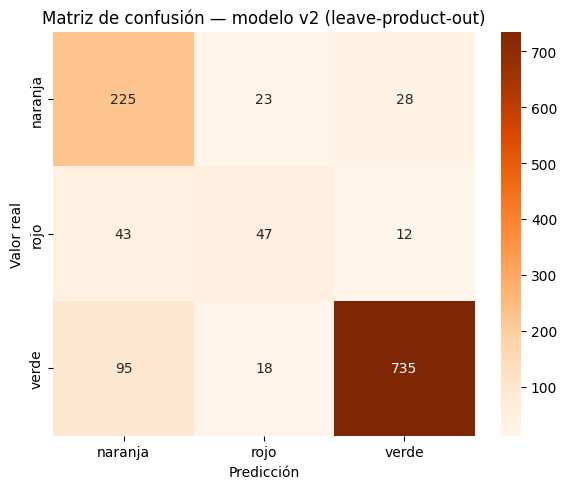

In [6]:
# 5c. Análisis de errores del modelo v2 (regresión logística texto+ contexto)
# Recogemos predicciones out-of-fold: cada producto se predice cuando está en
# el test de su partición. Así la matriz refleja el comportamiento real con
# productos nuevos, no vistos en entrenamiento.
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

pred_oof = np.empty(len(features), dtype=int)
for tr, te in gkf.split(features, y, grupos):
    pipe = Pipeline([('prep', prep_v2()),
                     ('clf', LogisticRegression(max_iter=2000, C=3.0,
                                                class_weight='balanced'))])
    pipe.fit(features.iloc[tr], y[tr])
    pred_oof[te] = pipe.predict(features.iloc[te])

print(classification_report(y, pred_oof, target_names=le.classes_))

cm = confusion_matrix(y, pred_oof)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicción'); ax.set_ylabel('Valor real')
ax.set_title('Matriz de confusión — modelo v2 (leave-product-out)')
plt.tight_layout(); plt.show()

In [7]:
# 5d. Qué productos ROJOS se le escapan al modelo?
# Un falso negativo en rojo = producto urgente que el modelo cree menos
# urgente. Es el error más grave para el usuario: comida que se estropea
# sin aviso. Los inspeccionamos uno a uno
errores = features.copy()
errores['real'] = le.inverse_transform(y)
errores['predicho'] = le.inverse_transform(pred_oof)
errores = errores[errores['real'] != errores['predicho']]

fn_rojo = errores[(errores['real'] == 'rojo') & (errores['predicho'] != 'rojo')]
print(f"Errores totales: {len(errores)} de {len(features)}")
print(f"Falsos negativos en ROJO (los más graves): {len(fn_rojo)}")
print()
print(fn_rojo[['nombre_es', 'estado', 'lugar', 'real', 'predicho']]
      .head(12).to_string(index=False))

Errores totales: 219 de 1226
Falsos negativos en ROJO (los más graves): 55

                                nombre_es  estado    lugar real predicho
                  Bagel - Recién horneado cerrado despensa rojo  naranja
      Pitahaya, Pitaya o Fruta del dragón cerrado despensa rojo  naranja
             Rollos de canela - Horneados cerrado despensa rojo    verde
            Crema - Para batir, endulzada cerrado   nevera rojo  naranja
            Huevos - Yemas de huevo crudo cerrado   nevera rojo  naranja
           Pechugas rellenas, sin cocinar cerrado   nevera rojo  naranja
Brochetas o pinchos crudos, con vegetales cerrado   nevera rojo  naranja
               Carne de cangrejo - Fresco cerrado   nevera rojo  naranja
                              Albaricoque cerrado   nevera rojo  naranja
                                 Guayabas cerrado   nevera rojo  naranja
                           Pastas frescas cerrado   nevera rojo    verde
            Mezcla de salsa (gravy), seca cerrad

In [8]:
# 5e. Decisión sensible al coste: Cuánto ayuda ponderar la clase crítica?
# Comparamos el mismo modelo v2 con y sin class_weight='balanced', mirando el
# recall de 'rojo'. En seguridad alimentaria se prefiere una falsa alarma antes
# que dejar pasar un producto urgente
def oof_pred(ponderar):
    p = np.empty(len(features), dtype=int)
    for tr, te in gkf.split(features, y, grupos):
        cw = 'balanced' if ponderar else None
        pipe = Pipeline([('prep', prep_v2()),
                         ('clf', LogisticRegression(max_iter=2000, C=3.0, class_weight=cw))])
        pipe.fit(features.iloc[tr], y[tr])
        p[te] = pipe.predict(features.iloc[te])
    return p

print(f"{'Configuración':26} {'recall rojo':>12} {'precision rojo':>15}")
for etiqueta, ponderar in [('Sin ponderar', False), ('Ponderando (balanced)', True)]:
    rep = classification_report(y, oof_pred(ponderar), target_names=le.classes_,
                                output_dict=True)
    print(f"{etiqueta:26} {rep['rojo']['recall']:>12.2f} {rep['rojo']['precision']:>15.2f}")

Configuración               recall rojo  precision rojo
Sin ponderar                       0.33            0.77
Ponderando (balanced)              0.46            0.53


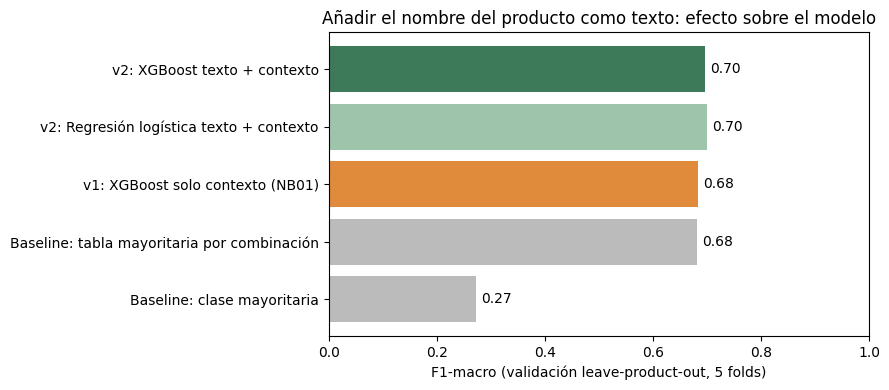

In [9]:
# 6. Gráfica comparativa (para la memoria)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(comparativa['Modelo'], comparativa['F1-macro'], color=['#BBBBBB', '#BBBBBB', '#E08A3C', '#9EC5AB', '#3D7A5A'])
for i, v in enumerate(comparativa['F1-macro']):
    ax.text(v + 0.01, i, f"{v:.2f}", va='center')
ax.set_xlim(0, 1); ax.set_xlabel('F1-macro (validación leave-product-out, 5 folds)')
ax.set_title('Añadir el nombre del producto como texto: efecto sobre el modelo')
plt.tight_layout(); plt.show()

## 5. Modelo final e interpretabilidad

Elegimos el mejor v2 por F1-macro. Si es la regresión logística, sus coeficientes dicen directamente qué palabras empujan hacia cada clase. Si es XGBoost, usamos la importancia de variables sobre los nombres de las *features* del TF-IDF.

In [10]:
# 7. Entrenar el modelo final con todos los datos y guardarlo
mejor = comparativa.iloc[3:].sort_values('F1-macro', ascending=False).iloc[0]['Modelo']
print("Modelo elegido:", mejor)

if 'logística' in mejor:
    modelo_v2 = Pipeline([('prep', prep_v2()),
                          ('clf', LogisticRegression(max_iter=2000, C=3.0, class_weight='balanced'))])
    modelo_v2.fit(features, y)
else:
    modelo_v2 = Pipeline([('prep', prep_v2()), ('clf', xgb())])
    modelo_v2.fit(features, y, clf__sample_weight=compute_sample_weight('balanced', y))

joblib.dump(modelo_v2, RUTA + 'modelo_v2.pkl')
joblib.dump(le, RUTA + 'label_encoder_v2.pkl')
print("Guardados modelo_v2.pkl y label_encoder_v2.pkl. Clases:", list(le.classes_))

Modelo elegido: v2: Regresión logística texto + contexto
Guardados modelo_v2.pkl y label_encoder_v2.pkl. Clases: ['naranja', 'rojo', 'verde']


In [11]:
# 8. Interpretabilidad: qué palabras del nombre empujan hacia cada urgencia
nombres_feat = modelo_v2.named_steps['prep'].get_feature_names_out()
clf = modelo_v2.named_steps['clf']

if hasattr(clf, 'coef_'):
    for k, clase in enumerate(le.classes_):
        top = np.argsort(clf.coef_[k])[::-1][:12]
        print(f"\n{clase.upper():8s} <- " + ", ".join(nombres_feat[i].replace('txt__', '').replace('ctx__', '') for i in top))
else:
    imp = pd.Series(clf.feature_importances_, index=nombres_feat).sort_values(ascending=False).head(20)
    print(imp.to_string())


NARANJA  <- categoria_es_Congelados, frutas, comercialmente, lugar_nevera, leche, categoria_es_Carne procesada, mejillones ostras, categoria_es_Carne fresca, caldo, pan integral, fruta, categoria_es_Platos preparados

ROJO     <- categoria_es_Pollo fresco, pate, molida, verduras, donas, categoria_es_Marisco, carne molida, mariscos enlatado, gravy, pudin, categoria_es_Carne preparada, categoria_es_Pescado fresco

VERDE    <- lugar_congelador, categoria_es_Repostería y cocina, categoria_es_Productos no perecederos, categoria_es_Condimentos y conservas, categoria_es_Cereales, legumbres y pasta, calabaza, cafe, datiles, manzanas, secas, seco, rayado


In [12]:
# 9. Prueba con productos que NO están en el catálogo FoodKeeper
nuevos = pd.DataFrame([
    {'nombre_es': 'Yogur griego de cabra',        'categoria_es': 'Lácteos y huevos',        'estado': 'abierto', 'lugar': 'nevera',   'referencia': 'compra'},
    {'nombre_es': 'Garbanzos cocidos en bote',    'categoria_es': 'Condimentos y conservas', 'estado': 'abierto', 'lugar': 'nevera',   'referencia': 'compra'},
    {'nombre_es': 'Garbanzos cocidos en bote',    'categoria_es': 'Condimentos y conservas', 'estado': 'cerrado', 'lugar': 'despensa', 'referencia': 'compra'},
    {'nombre_es': 'Salmón fresco en lomos',       'categoria_es': 'Pescado fresco',          'estado': 'cerrado', 'lugar': 'nevera',   'referencia': 'compra'},
    {'nombre_es': 'Pan de molde integral',        'categoria_es': 'Panadería',               'estado': 'abierto', 'lugar': 'despensa', 'referencia': 'compra'},
    {'nombre_es': 'Lentejas secas',               'categoria_es': 'Cereales, legumbres y pasta', 'estado': 'cerrado', 'lugar': 'despensa', 'referencia': 'compra'},
])
nuevos['urgencia_predicha'] = le.inverse_transform(modelo_v2.predict(nuevos))
nuevos[['nombre_es', 'estado', 'lugar', 'urgencia_predicha']]

,nombre_es,estado,lugar,urgencia_predicha
0,Yogur griego de cabra,abierto,nevera,naranja
1,Garbanzos cocidos en bote,abierto,nevera,verde
2,Garbanzos cocidos en bote,cerrado,despensa,verde
3,Salmón fresco en lomos,cerrado,nevera,rojo
4,Pan de molde integral,abierto,despensa,verde
5,Lentejas secas,cerrado,despensa,verde


In [13]:
# 10. requirements.txt único y con versiones fijadas
import sklearn, xgboost
req = (f"streamlit\npandas=={pd.__version__}\nnumpy=={np.__version__}\n"
       f"scikit-learn=={sklearn.__version__}\nxgboost=={xgboost.__version__}\n"
       f"joblib=={joblib.__version__}\npyarrow\n")
open(RUTA + 'requirements.txt', 'w').write(req)
print(req)
print("Sube al repo: vida_util_app.parquet, modelo_v2.pkl, label_encoder_v2.pkl, requirements.txt")

streamlit
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.9.1
xgboost==3.4.1
joblib==1.6.0
pyarrow

Sube al repo: vida_util_app.parquet, modelo_v2.pkl, label_encoder_v2.pkl, requirements.txt
